In [14]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [15]:
load_dotenv()

True

In [16]:
model = ChatOpenAI(
    model="openai/gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    temperature=0.2
)

In [17]:
class BlogState(TypedDict):

    title:str
    outline:str
    content:str

In [18]:
def create_outline(state: BlogState) -> BlogState:
    # fetch title
    title = state['title']
    # call llm gen outline
    prompt = f' Generate a detailed outline for a blog on the topic -> {title}'
    # ask que to the llm
    outline = model.invoke(prompt).content
    # update state
    state['outline'] = outline

    return state

In [ ]:
def create_blog(state: BlogState) -> BlogState:
    # fetch title and outline
    title = state['title']
    outline = state['outline']
    
    #prompt generation 
    prompt = f'Write a detailed blog on the title - {title} using the following outline \n {outline}'

    # ask llm to gen blog
    content = model.invoke(prompt).content

    # update state
    state['content'] = content

    return state

In [20]:
graph = StateGraph(BlogState)

# add node
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog',create_blog)

# add edges
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)

workflow = graph.compile()

In [21]:
initial_state = {'title': 'About Vaibhav sooryavanshi ipl'}
final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'About Vaibhav sooryavanshi ipl', 'outline': '# Blog Outline: About Vaibhav Sooryavanshi in IPL\n\n## Introduction\n- Brief introduction to the Indian Premier League (IPL)\n- Importance of emerging players in the league\n- Introduction to Vaibhav Sooryavanshi as a rising star\n\n## Section 1: Who is Vaibhav Sooryavanshi?\n- **1.1 Early Life**\n  - Birthplace and date\n  - Family background and early influences\n  - Initial interest in cricket\n\n- **1.2 Cricketing Journey**\n  - Early training and coaching\n  - Participation in local and state-level tournaments\n  - Key milestones in his youth career\n\n## Section 2: Vaibhav Sooryavanshi’s IPL Career\n- **2.1 Entry into IPL**\n  - Year of debut and team affiliation\n  - Initial performance and impact on the team\n\n- **2.2 Playing Style and Skills**\n  - Batting and bowling style\n  - Key strengths and areas of improvement\n  - Comparison with other players in the league\n\n- **2.3 Notable Performances**\n  - Highlight stando

In [22]:
print(final_state['outline'])

# Blog Outline: About Vaibhav Sooryavanshi in IPL

## Introduction
- Brief introduction to the Indian Premier League (IPL)
- Importance of emerging players in the league
- Introduction to Vaibhav Sooryavanshi as a rising star

## Section 1: Who is Vaibhav Sooryavanshi?
- **1.1 Early Life**
  - Birthplace and date
  - Family background and early influences
  - Initial interest in cricket

- **1.2 Cricketing Journey**
  - Early training and coaching
  - Participation in local and state-level tournaments
  - Key milestones in his youth career

## Section 2: Vaibhav Sooryavanshi’s IPL Career
- **2.1 Entry into IPL**
  - Year of debut and team affiliation
  - Initial performance and impact on the team

- **2.2 Playing Style and Skills**
  - Batting and bowling style
  - Key strengths and areas of improvement
  - Comparison with other players in the league

- **2.3 Notable Performances**
  - Highlight standout matches and statistics
  - Impactful innings or bowling spells
  - Contributions t

In [23]:
print(final_state['content'])

# About Vaibhav Sooryavanshi in IPL

## Introduction

The Indian Premier League (IPL) has become a global phenomenon, captivating cricket fans with its electrifying matches and showcasing some of the best talents in the sport. Each season, the league not only features established stars but also provides a platform for emerging players to shine. One such rising star is Vaibhav Sooryavanshi, whose journey in the IPL has been nothing short of inspiring. In this blog, we will delve into the life and career of Vaibhav Sooryavanshi, exploring his early beginnings, his impact in the IPL, and what the future holds for this promising cricketer.

## Section 1: Who is Vaibhav Sooryavanshi?

### 1.1 Early Life
Vaibhav Sooryavanshi was born on [insert birth date] in [insert birthplace], India. Growing up in a family that valued sports, Vaibhav was introduced to cricket at a young age. His father, an avid cricket fan, played a significant role in nurturing his interest in the game. Vaibhav's early e

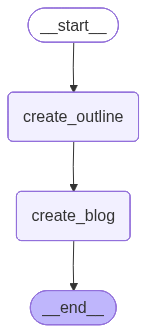

In [24]:
## to see the graph 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
# in langchain we only get content not outline due to state concept